EXPERIMENT 08 - TASK 01
Artificial Neural Network using Keras
Name    : R. Karthik
Roll No : 25EU02904

Dataset Shape:
(768, 9)

ANN Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 289 (1.13 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 0 (0.00 B)


Training completed.

Test Accuracy: 74.68%

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81       100
           1       0.67      0.56      0.61        54

    accuracy                           0.75       154
   macro avg       0.72      0.70      0.71       154
weighted avg       0.74      0.75      0.74       154


Confusion Matrix:
[[85 15]
 [24 30]]


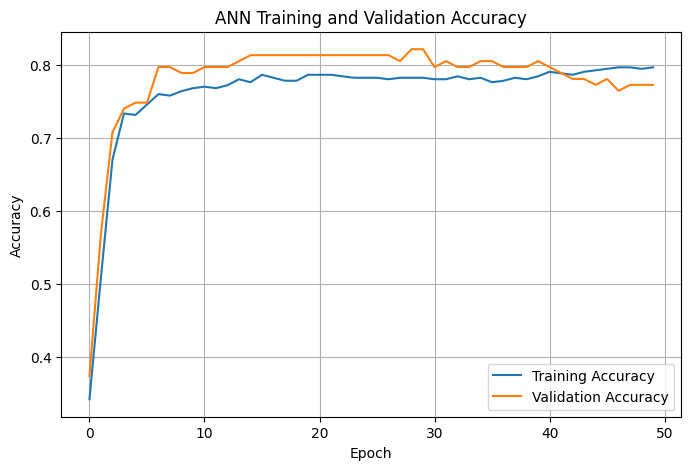


TASK 01 COMPLETED SUCCESSFULLY
Name    : R. Karthik
Roll No : 25EU02904


In [1]:
# ============================================================
# EXPERIMENT 08 - TASK 01
# Artificial Neural Network using Keras
# Pima Indians Diabetes Dataset
#
# Name    : R. Karthik
# Roll No : 25EU02904
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

print("=" * 60)
print("EXPERIMENT 08 - TASK 01")
print("Artificial Neural Network using Keras")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)

# ------------------------------------------------------------
# 1. Load Pima Indians Diabetes Dataset
# ------------------------------------------------------------

url = (
    "https://raw.githubusercontent.com/"
    "jbrownlee/Datasets/master/"
    "pima-indians-diabetes.data.csv"
)

columns = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df = pd.read_csv(
    url,
    header=None,
    names=columns
)

print("\nDataset Shape:")
print(df.shape)

# ------------------------------------------------------------
# 2. Separate Features and Target
# ------------------------------------------------------------

X = df.drop(
    "Outcome",
    axis=1
)

y = df["Outcome"]

# ------------------------------------------------------------
# 3. Replace Invalid Zero Values
# ------------------------------------------------------------

invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X[invalid_columns] = (
    X[invalid_columns]
    .replace(0, np.nan)
)

# Fill missing values with median
X = X.fillna(
    X.median()
)

# ------------------------------------------------------------
# 4. Train-Test Split
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# ------------------------------------------------------------
# 5. Feature Scaling
# ------------------------------------------------------------

scaler = StandardScaler()

X_train = scaler.fit_transform(
    X_train
)

X_test = scaler.transform(
    X_test
)

# ------------------------------------------------------------
# 6. Build ANN Architecture
# ------------------------------------------------------------

ann = Sequential([
    Dense(
        16,
        activation="relu",
        input_shape=(X_train.shape[1],)
    ),

    Dense(
        8,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

# ------------------------------------------------------------
# 7. Compile ANN
# ------------------------------------------------------------

ann.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nANN Architecture:")
ann.summary()

# ------------------------------------------------------------
# 8. Train ANN
# ------------------------------------------------------------

history = ann.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=50,
    batch_size=16,
    verbose=0
)

print("\nTraining completed.")

# ------------------------------------------------------------
# 9. Evaluate Model
# ------------------------------------------------------------

test_loss, test_accuracy = ann.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(
    f"\nTest Accuracy: "
    f"{test_accuracy * 100:.2f}%"
)

# ------------------------------------------------------------
# 10. Predictions
# ------------------------------------------------------------

probabilities = ann.predict(
    X_test,
    verbose=0
).ravel()

predictions = (
    probabilities >= 0.5
).astype(int)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        predictions
    )
)

# ------------------------------------------------------------
# 11. Learning Curves
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "ANN Training and Validation Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

# ------------------------------------------------------------
# Conclusion
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TASK 01 COMPLETED SUCCESSFULLY")
print("Name    : R. Karthik")
print("Roll No : 25EU02904")
print("=" * 60)